<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW1/HW1_CIFAR10_CNN_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW1

https://github.com/JordanTerwilliger/Intro-to-Deep-Learning

In [ ]:
import numpy as np

import torch as torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(1)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_data = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle = True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle = True, num_workers=2)

100%|██████████| 170M/170M [02:35<00:00, 1.10MB/s]


In [ ]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] # CIFAR-10 image classes

Alex Net consists of 8 Layers with a process of:

Input -> Conv2d -> Pooling -> Conv2d -> Pooling -> Conv2d -> Conv2d -> Conv2d -> Pooling -> Linear -> Linear -> Output

Using CIFAR-10 with this means that our pooling layers need a reduced stride or the layer can be removed altogether. The Conv2d layers can stay with 3x3 kernels with a reduced stride. We dont need 4096 neurons in the Linear layers, 128 or even 64 may suffice. LeNet which has 28x28 images uses 120 and then 84 for the Hidden Layers.

In [ ]:
class ModifiedAlex(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 16, 3, padding=0)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(16,32,3, padding =0)
    self.fc1 = nn.Linear(32*6*6,120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84,10)

  def forward(self,x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [ ]:
net = ModifiedAlex()
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [ ]:
epochs = 10
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs
    labels = labels

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.6033, Validation Accuracy: 26.61, Validation Loss: 12.99995176289409
Epoch: 1, Loss: 2.1701, Validation Accuracy: 40.12, Validation Loss: 10.836820909009575
Epoch: 2, Loss: 1.8507, Validation Accuracy: 44.24, Validation Loss: 9.241504826294348
Epoch: 3, Loss: 1.6748, Validation Accuracy: 50.23, Validation Loss: 8.363441186971938
Epoch: 4, Loss: 1.5543, Validation Accuracy: 54.42, Validation Loss: 7.761424005222016
Epoch: 5, Loss: 1.4557, Validation Accuracy: 58.08, Validation Loss: 7.26919478958788
Epoch: 6, Loss: 1.3653, Validation Accuracy: 60.68, Validation Loss: 6.817981907830071
Epoch: 7, Loss: 1.2917, Validation Accuracy: 61.21, Validation Loss: 6.45046738075753
Epoch: 8, Loss: 1.2230, Validation Accuracy: 63.72, Validation Loss: 6.107086558882802
Epoch: 9, Loss: 1.1666, Validation Accuracy: 65.37, Validation Loss: 5.825580742888557


In [ ]:
from torchsummary import summary
import torch

# Check if a GPU is available and move the model to it
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net.to(device)

# summary will automatically create an input tensor on the correct device if the model is already there
print(summary(net, input_size=(3,32,32)))

# ----------------------------------------------------------------
#         Layer (type)               Output Shape         Param #
# ================================================================
#             Conv2d-1           [-1, 16, 32, 32]             448
#          MaxPool2d-2           [-1, 16, 16, 16]               0
#             Conv2d-3           [-1, 16, 16, 16]           2,320
#          MaxPool2d-4             [-1, 16, 8, 8]               0
#             Linear-5                  [-1, 120]         123,000
#             Linear-6                   [-1, 84]          10,164
#             Linear-7                   [-1, 10]             850
# ================================================================
# Total params: 136,782
# Trainable params: 136,782
# Non-trainable params: 0
# ----------------------------------------------------------------
# Input size (MB): 0.01
# Forward/backward pass size (MB): 0.20
# Params size (MB): 0.52
# Estimated Total Size (MB): 0.73
# ----------------------------------------------------------------
# None

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 30, 30]             448
         MaxPool2d-2           [-1, 16, 15, 15]               0
            Conv2d-3           [-1, 32, 13, 13]           4,640
         MaxPool2d-4             [-1, 32, 6, 6]               0
            Linear-5                  [-1, 120]         138,360
            Linear-6                   [-1, 84]          10,164
            Linear-7                   [-1, 10]             850
Total params: 154,462
Trainable params: 154,462
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.19
Params size (MB): 0.59
Estimated Total Size (MB): 0.79
----------------------------------------------------------------
None


## Visualizing Filters in the First Convolutional Layer

Let's visualize the filters learned by the first convolutional layer (`conv1`). These filters represent the features that the network is looking for in the input images.

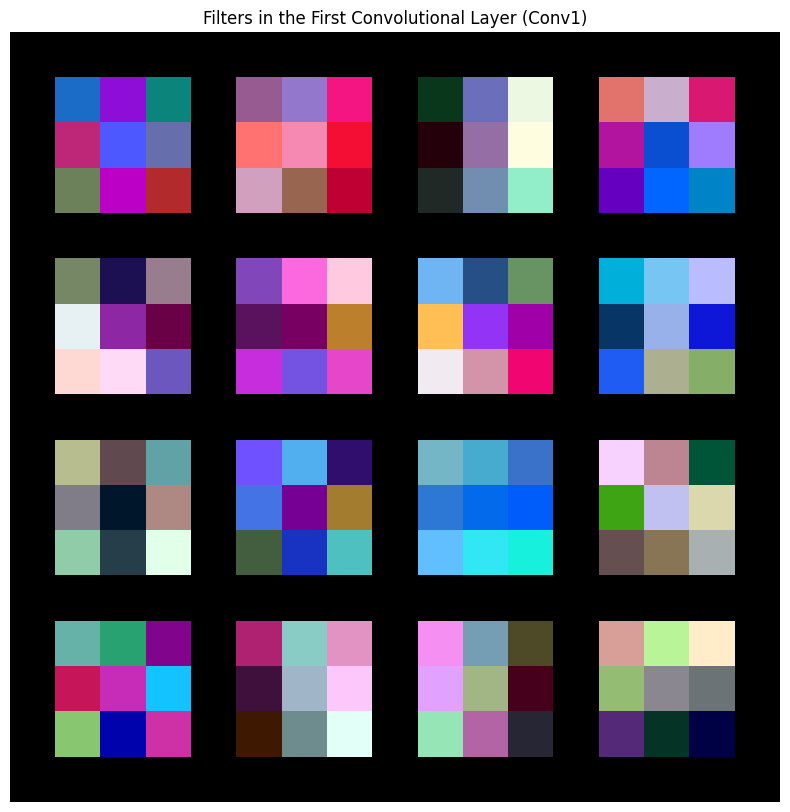

In [ ]:
import torchvision.utils as vutils

# Get the weights from the first convolutional layer
# The shape of conv1.weight is (out_channels, in_channels, kernel_height, kernel_width)
weights = net.conv1.weight.cpu().detach()

# Normalize the weights for visualization (e.g., to range [0, 1])
# This normalization is per filter channel, then across all filters.
# Min-max normalization for each filter to make it visible

# For 3-channel input filters, we can visualize them directly.
# Reshape to (out_channels, kernel_height, kernel_width, in_channels)
# Then normalize each filter independently

# Let's visualize the filters for each input channel separately, or as RGB if possible
# For simplicity, we'll average across input channels or take the first channel if not RGB

# If the input channel is 3 (RGB), we can display these directly
# If it's more or less, we might need to adjust or average

# Given `conv1 = nn.Conv2d(3, 16, 3, padding=1)`, weights shape is [16, 3, 3, 3]
# We want to display 16 filters, each as a 3x3 RGB image

fig = plt.figure(figsize=(10, 10))

# Create a grid of images for the filters
grid_img = vutils.make_grid(weights, normalize=True, scale_each=True, nrow=4, padding=1)

# Adjust the dimensions for matplotlib (from C, H, W to H, W, C)
plt.imshow(grid_img.permute(1, 2, 0))
plt.title('Filters in the First Convolutional Layer (Conv1)')
plt.axis('off')
plt.show()


In [ ]:
class ModifiedAlexDropout(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 16, 3, padding=0)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(16,32,3, padding =0)
    self.fc1 = nn.Linear(32*6*6,120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84,10)
    self.dropout = nn.Dropout(p=0.3)

  def forward(self,x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [ ]:
net = ModifiedAlex()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net.to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [ ]:
epochs = 30
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.6398, Validation Accuracy: 26.26, Validation Loss: 13.181959068051542
Epoch: 1, Loss: 2.1321, Validation Accuracy: 39.05, Validation Loss: 10.64690177280682
Epoch: 2, Loss: 1.8274, Validation Accuracy: 48.25, Validation Loss: 9.125381051922759
Epoch: 3, Loss: 1.6736, Validation Accuracy: 51.45, Validation Loss: 8.357458138237366
Epoch: 4, Loss: 1.5441, Validation Accuracy: 55.7, Validation Loss: 7.710583202374248
Epoch: 5, Loss: 1.4454, Validation Accuracy: 58.3, Validation Loss: 7.217934541237621
Epoch: 6, Loss: 1.3604, Validation Accuracy: 59.77, Validation Loss: 6.793438618746809
Epoch: 7, Loss: 1.2831, Validation Accuracy: 62.07, Validation Loss: 6.4074827920133695
Epoch: 8, Loss: 1.2203, Validation Accuracy: 62.34, Validation Loss: 6.093847701153435
Epoch: 9, Loss: 1.1647, Validation Accuracy: 64.74, Validation Loss: 5.816297069144325
Epoch: 10, Loss: 1.1085, Validation Accuracy: 65.65, Validation Loss: 5.5352531655337485
Epoch: 11, Loss: 1.0587, Validation Accur

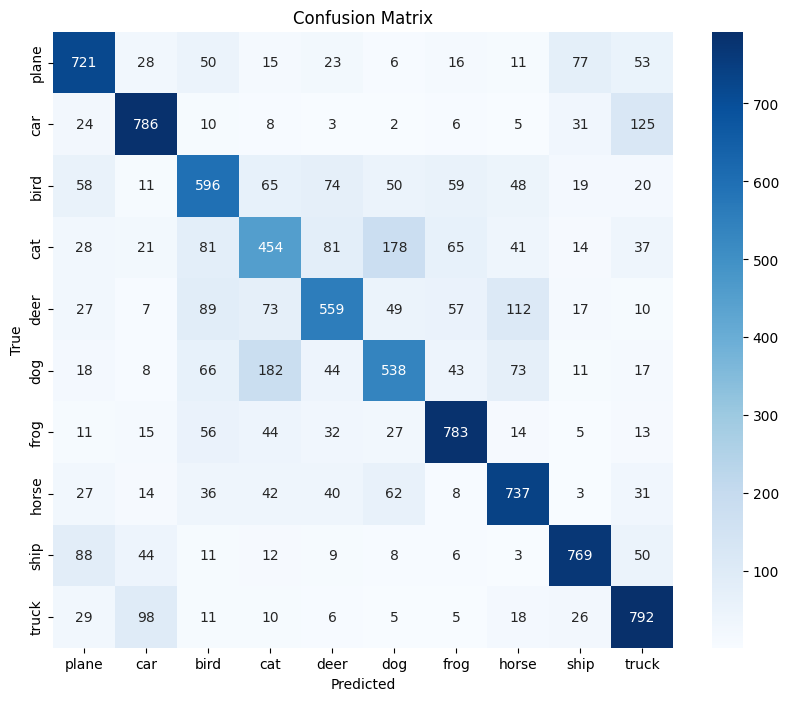

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Set the model to evaluation mode
net.eval()

all_labels = []
all_predictions = []

# Iterate over the test dataset to get all predictions
with torch.no_grad():
    for images, labels in test_loader:
        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Convert to DataFrame for better visualization with seaborn
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

#dropout p=0.3

In [ ]:
class ModifiedAlexDropout(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 16, 3, padding=0)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(16,32,3, padding =0)
    self.fc1 = nn.Linear(32*6*6,120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84,10)
    self.dropout = nn.Dropout(p=0.3)

  def forward(self,x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [ ]:
net = ModifiedAlexDropout().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [ ]:
epochs = 30
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.6568, Validation Accuracy: 25.33, Validation Loss: 13.266838419170806
Epoch: 1, Loss: 2.2153, Validation Accuracy: 38.5, Validation Loss: 11.062112239222175
Epoch: 2, Loss: 1.9511, Validation Accuracy: 44.05, Validation Loss: 9.742843933379689
Epoch: 3, Loss: 1.8142, Validation Accuracy: 47.74, Validation Loss: 9.059556588959008
Epoch: 4, Loss: 1.7077, Validation Accuracy: 50.58, Validation Loss: 8.527413338898851
Epoch: 5, Loss: 1.6219, Validation Accuracy: 53.97, Validation Loss: 8.099085221846645
Epoch: 6, Loss: 1.5433, Validation Accuracy: 55.91, Validation Loss: 7.706681563069645
Epoch: 7, Loss: 1.4784, Validation Accuracy: 57.57, Validation Loss: 7.382657089743751
Epoch: 8, Loss: 1.4185, Validation Accuracy: 59.71, Validation Loss: 7.083382409791977
Epoch: 9, Loss: 1.3651, Validation Accuracy: 60.61, Validation Loss: 6.816720361336351
Epoch: 10, Loss: 1.3118, Validation Accuracy: 62.31, Validation Loss: 6.550747786086207
Epoch: 11, Loss: 1.2661, Validation Accur

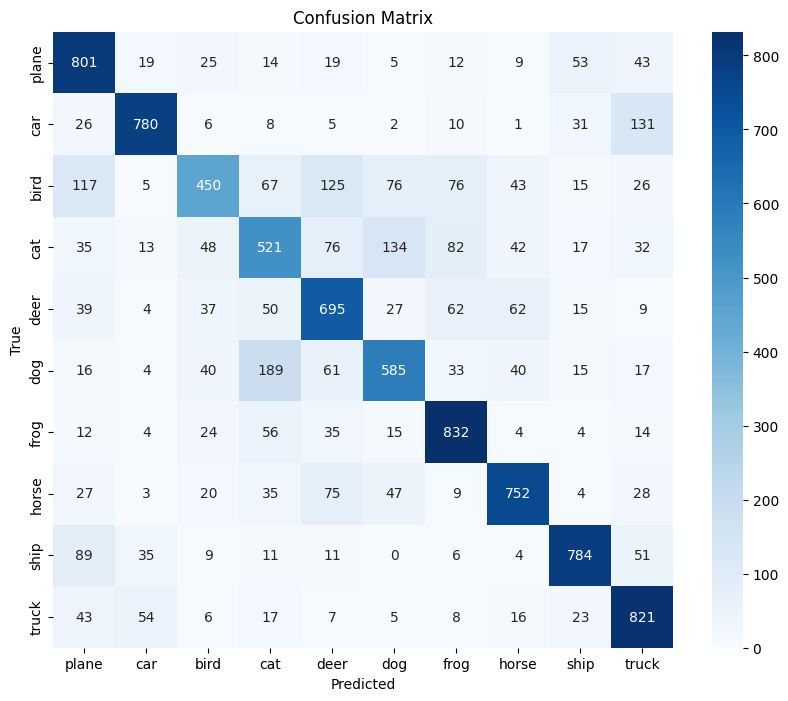

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Set the model to evaluation mode
net.eval()

all_labels = []
all_predictions = []

# Iterate over the test dataset to get all predictions
with torch.no_grad():
    for images, labels in test_loader:
        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Convert to DataFrame for better visualization with seaborn
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

#p=0.5

In [ ]:
class ModifiedAlexDropout(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 16, 3, padding=0)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(16,32,3, padding =0)
    self.fc1 = nn.Linear(32*6*6,120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84,10)
    self.dropout = nn.Dropout(p=0.5)

  def forward(self,x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [ ]:
net = ModifiedAlexDropout().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [ ]:
epochs = 30
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.6241, Validation Accuracy: 26.13, Validation Loss: 13.103836435860337
Epoch: 1, Loss: 2.2363, Validation Accuracy: 38.02, Validation Loss: 11.167184685746701
Epoch: 2, Loss: 1.9749, Validation Accuracy: 43.8, Validation Loss: 9.861881176884562
Epoch: 3, Loss: 1.8345, Validation Accuracy: 47.51, Validation Loss: 9.160661717573294
Epoch: 4, Loss: 1.7433, Validation Accuracy: 51.12, Validation Loss: 8.705147065293675
Epoch: 5, Loss: 1.6660, Validation Accuracy: 53.26, Validation Loss: 8.319344509333467
Epoch: 6, Loss: 1.5960, Validation Accuracy: 55.8, Validation Loss: 7.969797405762414
Epoch: 7, Loss: 1.5345, Validation Accuracy: 57.73, Validation Loss: 7.662538273837239
Epoch: 8, Loss: 1.4744, Validation Accuracy: 59.32, Validation Loss: 7.362336678436389
Epoch: 9, Loss: 1.4249, Validation Accuracy: 60.43, Validation Loss: 7.115268449052073
Epoch: 10, Loss: 1.3817, Validation Accuracy: 61.3, Validation Loss: 6.899490189628479
Epoch: 11, Loss: 1.3409, Validation Accurac

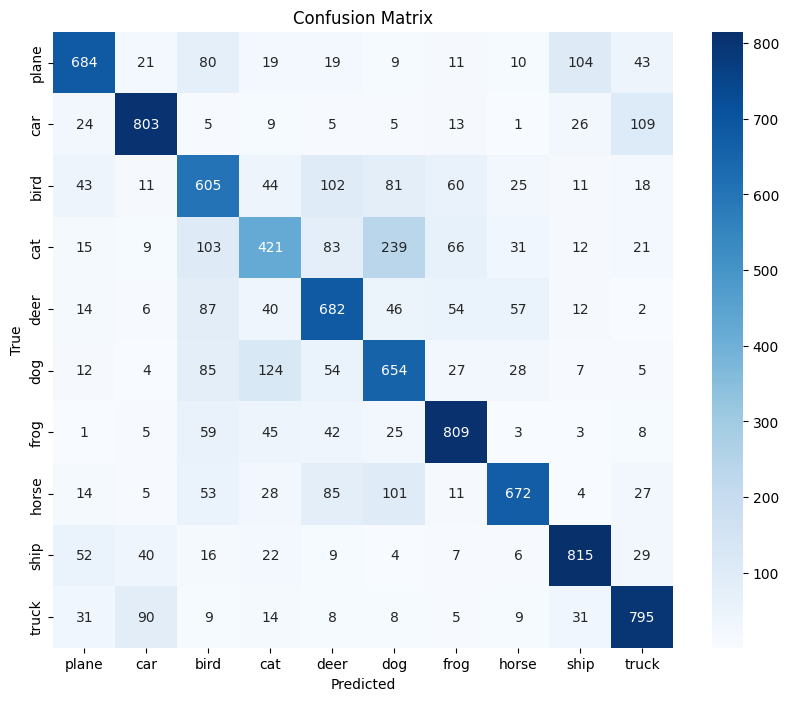

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Set the model to evaluation mode
net.eval()

all_labels = []
all_predictions = []

# Iterate over the test dataset to get all predictions
with torch.no_grad():
    for images, labels in test_loader:
        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Convert to DataFrame for better visualization with seaborn
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()